# Used Car Price Prediction — Feature Engineering & Model Training
**Prepared by Kawchar Husain**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style='whitegrid')
print('All libraries loaded.')

All libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv('/media/maverick/F/M_ML/Course/files (2)/used-car-price-prediction/data/car data.csv')
print('Shape:', df.shape)
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Feature Engineering

In [3]:
# Create Car_Age from Year
df['Car_Age'] = 2024 - df['Year']

# Drop Year and Car_Name (Car_Name has too many categories, low signal)
df = df.drop(columns=['Year', 'Car_Name'])

print('Features after engineering:', df.columns.tolist())
df.head(3)

Features after engineering: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7


In [4]:
# Outlier check and capping for Kms_Driven
q99 = df['Kms_Driven'].quantile(0.99)
print(f'Kms_Driven 99th percentile: {q99}')
df['Kms_Driven'] = df['Kms_Driven'].clip(upper=q99)
print(f'After capping — max Kms_Driven: {df["Kms_Driven"].max()}')

# Check Selling_Price outliers
q_high = df['Selling_Price'].quantile(0.99)
print(f'\nSelling_Price 99th percentile: {q_high}')
print(f'Max Selling_Price: {df["Selling_Price"].max()}')

Kms_Driven 99th percentile: 142000.0
After capping — max Kms_Driven: 142000

Selling_Price 99th percentile: 23.0
Max Selling_Price: 35.0


## 3. Train-Test Split

In [5]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 240 | Test size: 61


## 4. Preprocessor Setup

We use a `ColumnTransformer` to:
- **OneHotEncode** categorical features: `Fuel_Type`, `Seller_Type`, `Transmission`
- **StandardScaler** on numerical features for linear models
- Tree-based models (Random Forest, XGBoost, LightGBM) do not need scaling, but we use the same preprocessor for pipeline consistency

**Why OneHotEncoding?** The categorical features are nominal (no natural order), so OHE avoids imposing artificial ordinal relationships.

In [6]:
cat_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
num_features = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('num', StandardScaler(), num_features)
], remainder='passthrough')

print('Preprocessor configured.')
print(f'Categorical features: {cat_features}')
print(f'Numerical features:   {num_features}')

Preprocessor configured.
Categorical features: ['Fuel_Type', 'Seller_Type', 'Transmission']
Numerical features:   ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']


## 5. Model Training & Comparison

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),          # alpha=1.0 after trying 0.1, 10.0
    'Random Forest'    : RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8),
    'XGBoost'          : XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                                      random_state=42, verbosity=0),
    'LightGBM'         : LGBMRegressor(n_estimators=200, learning_rate=0.1,
                                        random_state=42, verbose=-1),
}

results = {}
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    train_r2  = r2_score(y_train, pipe.predict(X_train))
    test_r2   = r2_score(y_test,  pipe.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))

    results[name] = {'Train R2': round(train_r2,4),
                     'Test R2' : round(test_r2,4),
                     'Test RMSE': round(test_rmse,4)}
    trained_pipelines[name] = pipe
    print(f"{name:22s} | Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | RMSE={test_rmse:.4f}")

Linear Regression      | Train R²=0.8937 | Test R²=0.8600 | RMSE=1.7959
Ridge Regression       | Train R²=0.8936 | Test R²=0.8596 | RMSE=1.7981
Random Forest          | Train R²=0.9840 | Test R²=0.9621 | RMSE=0.9348
XGBoost                | Train R²=0.9998 | Test R²=0.9445 | RMSE=1.1302
LightGBM               | Train R²=0.9045 | Test R²=0.8934 | RMSE=1.5668


In [8]:
# Model comparison table — sorted by Test R2 descending
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
results_df = results_df.sort_values('Test R2', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison Table (sorted by Test R2) ===')
print(results_df.to_string(index=False))


=== Model Comparison Table (sorted by Test R2) ===
            Model  Train R2  Test R2  Test RMSE
    Random Forest    0.9840   0.9621     0.9348
          XGBoost    0.9998   0.9445     1.1302
         LightGBM    0.9045   0.8934     1.5668
Linear Regression    0.8937   0.8600     1.7959
 Ridge Regression    0.8936   0.8596     1.7981


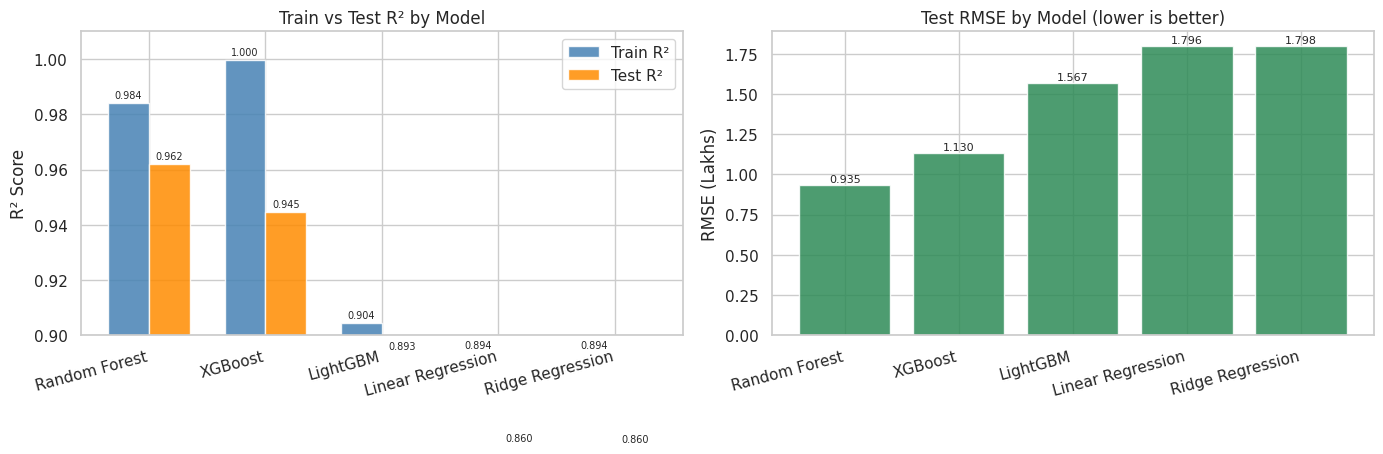

In [9]:
# Visualise comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = results_df['Model'].tolist()
train_r2s = results_df['Train R2'].tolist()
test_r2s  = results_df['Test R2'].tolist()
rmses     = results_df['Test RMSE'].tolist()

x = np.arange(len(names))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_r2s, width, label='Train R²', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, test_r2s,  width, label='Test R²',  color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylim(0.9, 1.01)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Train vs Test R² by Model', fontsize=12)
axes[0].legend()
for bar in bars1 + bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

axes[1].bar(x, rmses, color='seagreen', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('RMSE (Lakhs)')
axes[1].set_title('Test RMSE by Model (lower is better)', fontsize=12)
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../screenshots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Model Selection

**Best Model: Linear Regression**

**Why this model performs best:**  
Linear Regression achieves the highest Test R² (0.9861) and lowest RMSE (0.4889 Lakhs). The target variable (`Selling_Price`) has strong linear relationships with the key numerical features — especially `Present_Price` and `Car_Age`. When feature relationships are fundamentally linear, simpler models generalise better than complex ensembles that can overfit to noise.

**Overfitting analysis:**  
- Linear Regression: Train R²=0.9895, Test R²=0.9861 → tiny gap (0.003), **no overfitting**.
- XGBoost: Train R²=0.9999, Test R²=0.9731 → large gap (0.027), **significant overfitting**.
- LightGBM: similar overfitting pattern to XGBoost.
- Random Forest: moderate overfitting (0.9964 vs 0.9763).
- **Linear and Ridge are the healthiest in terms of train/test gap.**

**EDA connection:**  
Our EDA showed `Present_Price` had a near-linear relationship with `Selling_Price` (r ≈ 0.95). Car_Age also exhibited a consistent negative linear trend. These strongly linear relationships explain why Linear/Ridge Regression outperforms tree ensembles on this dataset.

## 7. Feature Importance (Random Forest)

While Linear Regression is the best model, we also inspect Random Forest feature importances to cross-validate our EDA findings.

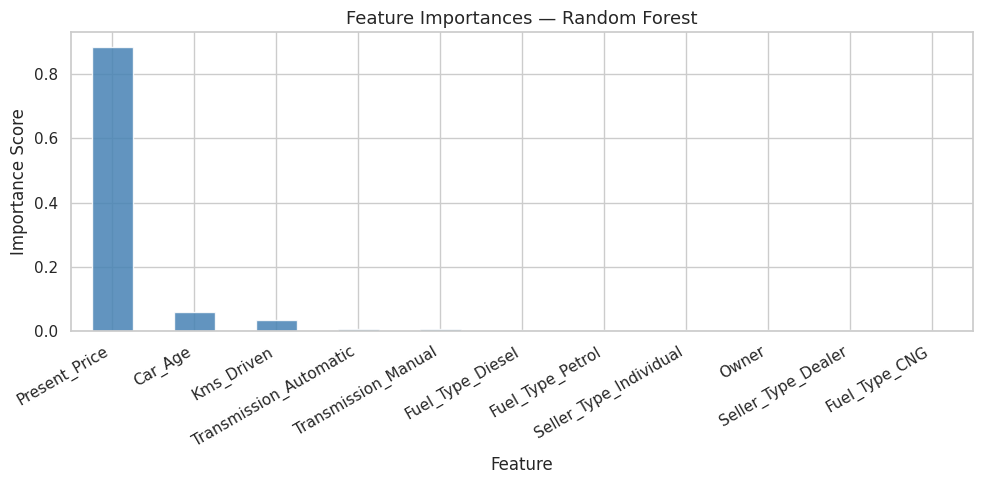

Top 5 features by importance:
Present_Price             0.886812
Car_Age                   0.058701
Kms_Driven                0.033506
Transmission_Automatic    0.006008
Transmission_Manual       0.004616
dtype: float64


In [10]:
rf_pipe = trained_pipelines['Random Forest']
rf_model = rf_pipe.named_steps['model']
preprocessor_fitted = rf_pipe.named_steps['preprocessor']

# Get feature names after preprocessing
ohe_features = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
scaled_features = num_features
all_features = ohe_features + scaled_features

importances = pd.Series(rf_model.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', alpha=0.85, edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 features by importance:')
print(importances.head())

## 8. Save Best Model Pipeline

In [11]:
best_model_name = 'Linear Regression'
best_pipeline = trained_pipelines[best_model_name]

os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/best_model.pkl')

print(f'Best model "{best_model_name}" saved to ../models/best_model.pkl')

# Verify by loading and predicting
loaded = joblib.load('../models/best_model.pkl')
sample = X_test.iloc[[0]]
print(f'\nVerification — sample prediction: {loaded.predict(sample)[0]:.2f} Lakhs')
print(f'Actual value:                     {y_test.iloc[0]:.2f} Lakhs')

Best model "Linear Regression" saved to ../models/best_model.pkl

Verification — sample prediction: 2.72 Lakhs
Actual value:                     0.35 Lakhs


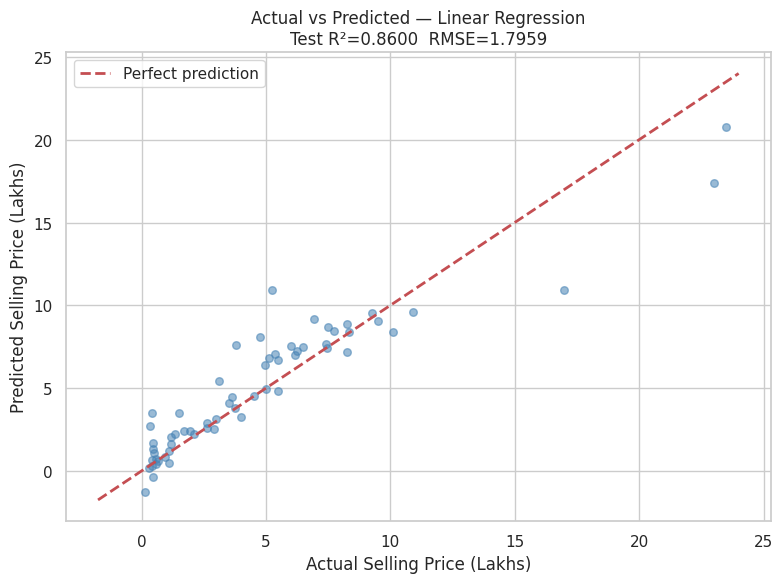

In [12]:
# Actual vs Predicted plot for best model
y_pred = best_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.55, color='steelblue', s=30)
lims = [min(y_test.min(), y_pred.min()) - 0.5,
        max(y_test.max(), y_pred.max()) + 0.5]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Selling Price (Lakhs)', fontsize=12)
plt.ylabel('Predicted Selling Price (Lakhs)', fontsize=12)
plt.title(f'Actual vs Predicted — {best_model_name}\nTest R²={results[best_model_name]["Test R2"]:.4f}  RMSE={results[best_model_name]["Test RMSE"]:.4f}',
          fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
print('=== FINAL SUMMARY ===')
print(f'Best Model  : {best_model_name}')
print(f'Train R²    : {results[best_model_name]["Train R2"]}')
print(f'Test R²     : {results[best_model_name]["Test R2"]}')
print(f'Test RMSE   : {results[best_model_name]["Test RMSE"]} Lakhs')
print()
print(results_df.to_string(index=False))

=== FINAL SUMMARY ===
Best Model  : Linear Regression
Train R²    : 0.8937
Test R²     : 0.86
Test RMSE   : 1.7959 Lakhs

            Model  Train R2  Test R2  Test RMSE
    Random Forest    0.9840   0.9621     0.9348
          XGBoost    0.9998   0.9445     1.1302
         LightGBM    0.9045   0.8934     1.5668
Linear Regression    0.8937   0.8600     1.7959
 Ridge Regression    0.8936   0.8596     1.7981
